# 🏥 Explainable VQA on GI Imaging — Interactive Demo
**Thesis:** Advancing Medical AI with Explainable VQA on GI Imaging  
**Author:** Ummay Hani Javed (24i-8211)

This notebook lets you test the full 4-stage pipeline live:
- Upload any GI endoscopy image
- Ask any clinical question
- Get: **Answer + GradCAM + Disease Vector + Textual Explanation + Confidence Scores**

---
### Pipeline:
```
Image + Question
  → Stage 1: Disease Classification  (ResNet50, 96.86%)
  → Stage 2: Question Routing        (DistilBERT, 93.01%)
  → Stage 3: Multimodal Fusion       (CrossAttn, 92.33%)
  → Stage 4: Answer Generation       (6 Heads, 73.97%)
  → Explainability: GradCAM + Report
```

## ⚙️ Cell 1 — Setup & Imports

In [1]:
print("")

In [2]:
import os, sys, warnings
warnings.filterwarnings('ignore')

# Add src to path (works from both ~/vqa_gi_thesis and ~/)
for p in [
    os.path.expanduser('~/vqa_gi_thesis/src'),
    os.path.expanduser('~'),
]:
    if p not in sys.path:
        sys.path.insert(0, p)

# Change working dir to project root so checkpoints are found
project_root = os.path.expanduser('~/vqa_gi_thesis')
os.chdir(project_root)
print(f'📁  Working directory: {os.getcwd()}')

import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from PIL import Image as PILImage
from IPython.display import display, HTML, Image as IPImage
import ipywidgets as widgets

print(f'🔥  Device: {"CUDA (" + torch.cuda.get_device_name(0) + ")" if torch.cuda.is_available() else "CPU"}')
print('✅  Setup complete')

📁  Working directory: /home/khuram/vqa_gi_thesis
🔥  Device: CUDA (NVIDIA GeForce RTX 5070)
✅  Setup complete



## 🔄 Cell 2 — Load Pipeline (run once)

In [7]:
import os, shutil, sys

# ── Force working dir to home where everything actually lives ──────────
os.chdir(os.path.expanduser('~'))
print(f'📁  Working dir: {os.getcwd()}')

# ── Make sure src is on path ───────────────────────────────────────────
for p in [os.path.expanduser('~'),
          os.path.expanduser('~/vqa_gi_thesis/src')]:
    if p not in sys.path:
        sys.path.insert(0, p)

# ── Fix data symlinks ──────────────────────────────────────────────────
os.makedirs('./data', exist_ok=True)

links = {
    './data/kvasir_local'    : './data/kvasir_local',
    './data/kvasir_raw'      : './data/kvasir_raw',
    './data/stage4_vocab.json': './data/stage4_vocab.json',
}
for dst, src in links.items():
    if not os.path.exists(dst):
        print(f'⚠️  Missing: {dst}')
    else:
        print(f'✅  Found: {dst}')

# ── Verify checkpoints ─────────────────────────────────────────────────
for ckpt in ['./checkpoints/stage1_best.pt',
             './checkpoints/stage3_best.pt',
             './checkpoints/stage4_best.pt']:
    status = '✅' if os.path.exists(ckpt) else '❌'
    print(f'{status}  {ckpt}')

print('\n✅  Path setup complete — now run Cell 2')

from explainability import ExplainabilityPredictor, plot_explainability_report

print('Loading full pipeline ... (this takes ~30 seconds)')
predictor = ExplainabilityPredictor()
print('\n🚀  Pipeline ready! Proceed to next cell.')

📁  Working dir: /home/khuram
✅  Found: ./data/kvasir_local
✅  Found: ./data/kvasir_raw
✅  Found: ./data/stage4_vocab.json
✅  ./checkpoints/stage1_best.pt
✅  ./checkpoints/stage3_best.pt
✅  ./checkpoints/stage4_best.pt

✅  Path setup complete — now run Cell 2
Loading full pipeline ... (this takes ~30 seconds)
🔍  Loading ExplainabilityPredictor ...
✅  TextPreprocessor ready  |  vocab=30,522  max_len=128
🔒  Backbone frozen — 0 trainable backbone parameters
🧠  TreeNet  |  total=24,177,495  trainable=669,463  frozen=23,508,032
   GradCAM target: backbone[7][-1].conv3  →  Conv2d  out_ch=2048
🔒  Backbone frozen — 0 trainable backbone parameters
🧠  TreeNet  |  total=24,177,495  trainable=669,463  frozen=23,508,032
🔒  FrozenVisualEncoder loaded  (stage1 best_f1=0.9925)


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: ./checkpoints/best_model
Key                   | Status     |  | 
----------------------+------------+--+-
pre_classifier.weight | UNEXPECTED |  | 
pre_classifier.bias   | UNEXPECTED |  | 
classifier.bias       | UNEXPECTED |  | 
classifier.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


🔒  FrozenTextEncoder loaded  (stage2 DistilBERT)

🧠  Stage3MultimodalFusion
    Total params     : 93,734,493
    Trainable        : 3,194,118  (CrossAttn + DiseaseGate + FusionMLP)
    Frozen           : 90,540,375  (ResNet50 + DistilBERT)
✅  FusionExtractor loaded  (best_acc=0.9250)

🧠  Stage4AnswerGenerator
    6 specialised heads  |  Total params: 925,827
    [yn      ] →    2 classes  |  138,242 params
    [single  ] →  200 classes  |  189,128 params
    [multi   ] →  150 classes  |  176,278 params
    [color   ] →   12 classes  |  140,812 params
    [loc     ] →   15 classes  |  141,583 params
    [count   ] →    8 classes  |  139,784 params
✅  ExplainabilityPredictor ready


🚀  Pipeline ready! Proceed to next cell.


## 🔬 Cell 3 — Single Prediction
Change `IMAGE_PATH` and `QUESTION` then run.

Question,Is there a polyp visible?
Answer,NO
Question Type,yes/no
Route Confidence,99.97%


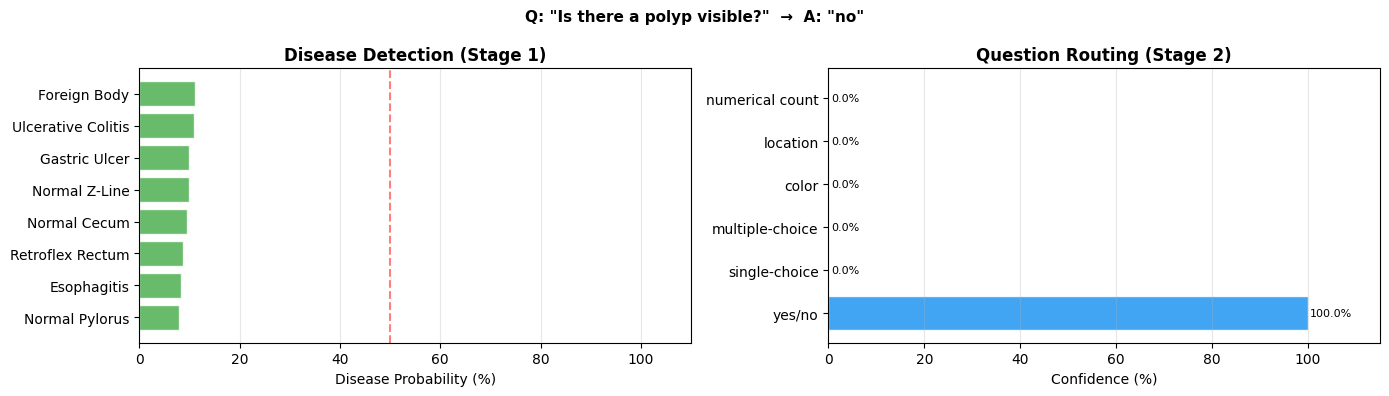


📊 Full report → ./logs/explainability/explain_Is_there_a_polyp_visible.png


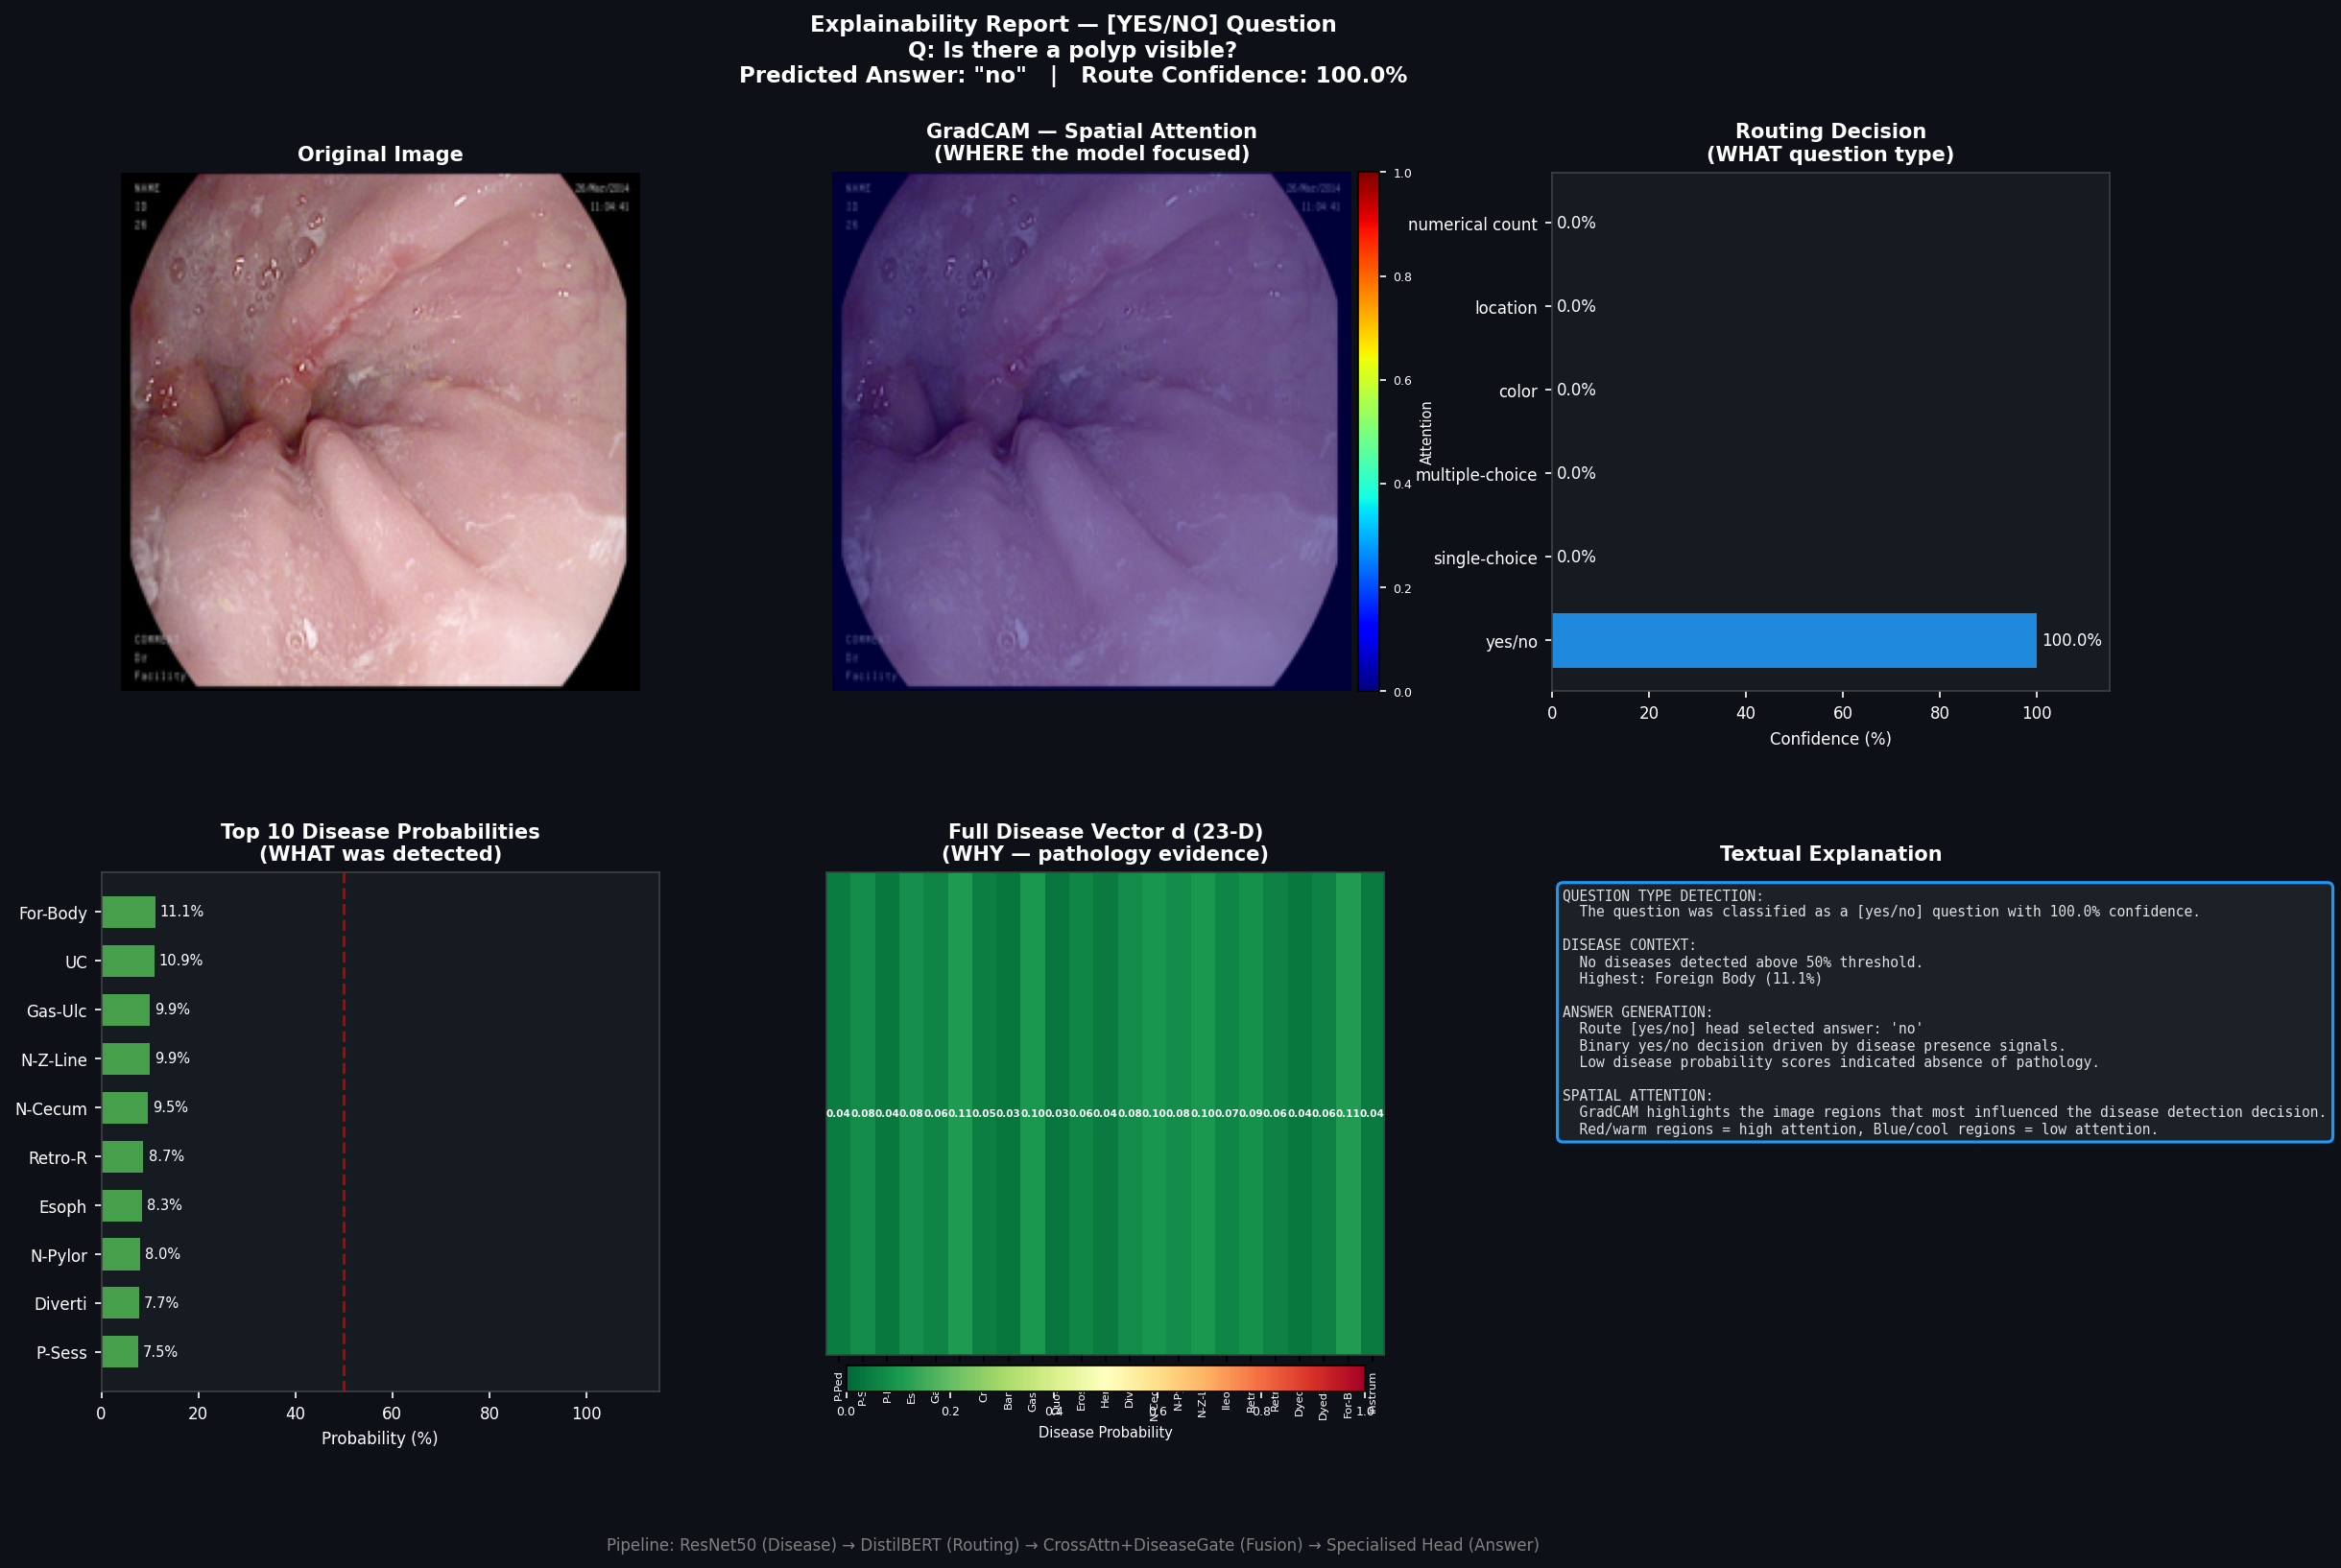

In [8]:
# ─── EDIT THESE ───────────────────────────────────────────────────────────
IMAGE_PATH = './data/kvasir_raw/images/clb0kvxvm90y4074yf50vf5nq.jpg'
QUESTION   = 'Is there a polyp visible?'
# ──────────────────────────────────────────────────────────────────────────

result = predictor.predict_full(IMAGE_PATH, QUESTION)

# ── Print structured output ───────────────────────────────────────────────
DISEASE_NAMES = [
    'Polyp (Pedunculated)','Polyp (Sessile)','Polyp (Hyperplastic)',
    'Esophagitis','Gastritis','Ulcerative Colitis',"Crohn's Disease",
    "Barrett's Esophagus",'Gastric Ulcer','Duodenal Ulcer',
    'Erosion','Hemorrhoids','Diverticulosis',
    'Normal Cecum','Normal Pylorus','Normal Z-Line',
    'Ileocecal Valve','Retroflex Rectum','Retroflex Stomach',
    'Dyed Lifted Polyp','Dyed Resection Margin','Foreign Body','Instrument'
]

display(HTML(f'''
<div style="font-family:monospace; background:#1e1e1e; color:#d4d4d4;
            padding:20px; border-radius:10px; font-size:14px">
<h3 style="color:#4ec9b0">🔍 VQA Prediction Result</h3>
<table style="width:100%; border-collapse:collapse">
  <tr><td style="color:#9cdcfe;padding:4px"><b>Question</b></td>
      <td style="padding:4px">{result["question"]}</td></tr>
  <tr><td style="color:#9cdcfe;padding:4px"><b>Answer</b></td>
      <td style="padding:4px; color:#4ec9b0; font-size:16px"><b>{result["answer"].upper()}</b></td></tr>
  <tr><td style="color:#9cdcfe;padding:4px"><b>Question Type</b></td>
      <td style="padding:4px">{result["route_name"]}</td></tr>
  <tr><td style="color:#9cdcfe;padding:4px"><b>Route Confidence</b></td>
      <td style="padding:4px; color:#dcdcaa">{result["route_conf"]*100:.2f}%</td></tr>
</table>
</div>
'''))

# ── Disease context bar chart ─────────────────────────────────────────────
d_vec   = result['disease_vec']
top8    = np.argsort(d_vec)[::-1][:8]
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

colors = ['#f44336' if d_vec[i]>=0.5 else '#ff9800' if d_vec[i]>=0.3
          else '#4caf50' for i in top8]
axes[0].barh([DISEASE_NAMES[i][:25] for i in top8[::-1]],
             [d_vec[i]*100 for i in top8[::-1]],
             color=colors[::-1], alpha=0.85, edgecolor='white')
axes[0].axvline(50, color='red', linestyle='--', alpha=0.5, lw=1.5)
axes[0].set_xlabel('Disease Probability (%)')
axes[0].set_title('Disease Detection (Stage 1)', fontweight='bold')
axes[0].set_xlim(0, 110)
axes[0].grid(axis='x', alpha=0.3)

# Routing confidence
QTYPE_NAMES  = ['yes/no','single-choice','multiple-choice','color','location','numerical count']
QTYPE_COLORS = ['#2196F3','#4CAF50','#FF9800','#9C27B0','#F44336','#00BCD4']
r = result['route']
bar_colors = [QTYPE_COLORS[i] if i==r else '#555555' for i in range(6)]
axes[1].barh(QTYPE_NAMES, result['route_probs']*100,
             color=bar_colors, alpha=0.85, edgecolor='white')
axes[1].set_xlabel('Confidence (%)')
axes[1].set_title('Question Routing (Stage 2)', fontweight='bold')
axes[1].set_xlim(0, 115)
axes[1].grid(axis='x', alpha=0.3)
for i, val in enumerate(result['route_probs']*100):
    axes[1].text(val+0.5, i, f'{val:.1f}%', va='center', fontsize=8)

plt.suptitle(f'Q: "{QUESTION}"  →  A: "{result["answer"]}"',
             fontweight='bold', fontsize=11)
plt.tight_layout()
plt.show()

# ── GradCAM + full report ─────────────────────────────────────────────────
report_path = plot_explainability_report(result)
print(f'\n📊 Full report → {report_path}')
display(IPImage(report_path, width=900))

## 🖼️ Cell 4 — Upload Your Own Image (Widget)

In [9]:
import io

uploader  = widgets.FileUpload(accept='image/*', multiple=False,
                                description='Upload GI Image')
q_text    = widgets.Text(value='Is there a polyp visible?',
                          description='Question:', layout=widgets.Layout(width='500px'))
run_btn   = widgets.Button(description='▶ Run Pipeline',
                            button_style='success',
                            layout=widgets.Layout(width='180px'))
out       = widgets.Output()

def on_run(b):
    out.clear_output()
    with out:
        if not uploader.value:
            print('⚠️  Please upload an image first')
            return
        # Save uploaded file
        fname  = list(uploader.value.keys())[0]
        fdata  = uploader.value[fname]['content']
        tmppath = f'/tmp/notebook_upload_{fname}'
        with open(tmppath, 'wb') as f:
            f.write(fdata)
        print(f'📁  Saved: {fname}  ({len(fdata)//1024} KB)')
        print(f'❓  Question: {q_text.value}')
        print('🔄  Running pipeline ...')

        result = predictor.predict_full(tmppath, q_text.value)

        print(f'\n✅  Answer: {result["answer"].upper()}')
        print(f'   Type   : {result["route_name"]}')
        print(f'   Conf   : {result["route_conf"]*100:.2f}%')

        report_path = plot_explainability_report(result)
        display(IPImage(report_path, width=900))

run_btn.on_click(on_run)
display(widgets.VBox([
    widgets.HTML('<h4>Upload a GI endoscopy image and ask a question:</h4>'),
    uploader, q_text, run_btn, out
]))

## 🎯 Cell 5 — Batch Test (Multiple Questions on Same Image)

🖼️  Image: clb0kvxvm90y4074yf50vf5nq.jpg
❓  Testing 6 questions

#    Question                                       Type                Answer                          Conf
---------------------------------------------------------------------------------------------------------
1    Is there a polyp visible?                      yes/no              no                              100.0%
2    What color is the finding?                     color               pink                            99.7%
3    Where is the finding located?                  location            esophagus                       99.9%
4    How many polyps are visible?                   numerical count     1                               100.0%
5    What abnormalities are present in the image?   single-choice       <unk>                           99.5%
6    Is this a normal colonoscopy image?            single-choice       <unk>                           97.6%


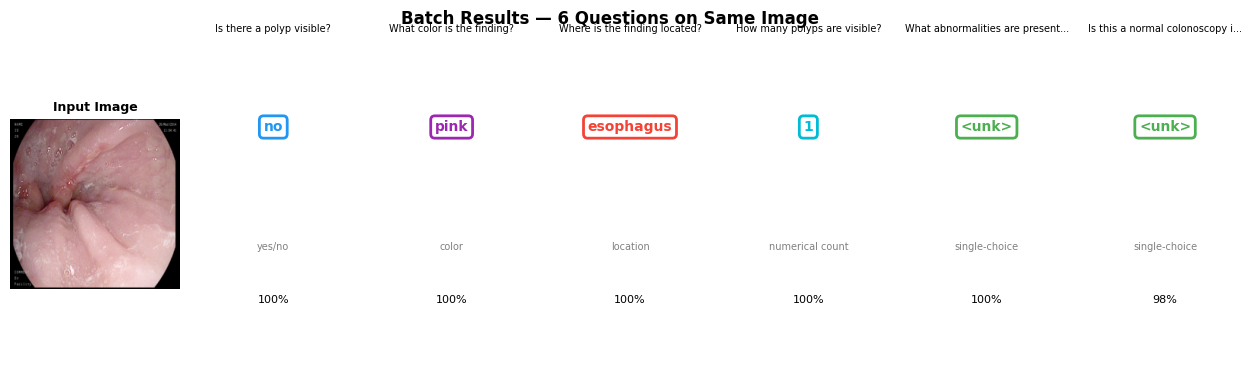

In [11]:
# ─── EDIT THESE ───────────────────────────────────────────────────────────
IMAGE_PATH = './data/kvasir_raw/images/clb0kvxvm90y4074yf50vf5nq.jpg'
QUESTIONS  = [
    'Is there a polyp visible?',
    'What color is the finding?',
    'Where is the finding located?',
    'How many polyps are visible?',
    'What abnormalities are present in the image?',
    'Is this a normal colonoscopy image?',
]
# ──────────────────────────────────────────────────────────────────────────

print(f'🖼️  Image: {os.path.basename(IMAGE_PATH)}')
print(f'❓  Testing {len(QUESTIONS)} questions\n')
print(f'{"#":<3}  {"Question":<45}  {"Type":<18}  {"Answer":<30}  {"Conf"}')
print('-' * 105)

results = []
for i, q in enumerate(QUESTIONS):
    r = predictor.predict_full(IMAGE_PATH, q)
    results.append(r)
    print(f'{i+1:<3}  {q[:44]:<45}  {r["route_name"]:<18}  '
          f'{r["answer"][:29]:<30}  {r["route_conf"]*100:.1f}%')

# Summary figure
img_pil = PILImage.open(IMAGE_PATH).convert('RGB').resize((224,224))
fig = plt.figure(figsize=(16, 4))
fig.suptitle(f'Batch Results — {len(QUESTIONS)} Questions on Same Image',
             fontweight='bold', fontsize=12)
gs  = gridspec.GridSpec(1, len(QUESTIONS)+1, figure=fig, wspace=0.05)

ax0 = fig.add_subplot(gs[0,0])
ax0.imshow(img_pil); ax0.axis('off')
ax0.set_title('Input Image', fontsize=9, fontweight='bold')

QTYPE_COLORS = ['#2196F3','#4CAF50','#FF9800','#9C27B0','#F44336','#00BCD4']
for j, r in enumerate(results):
    ax = fig.add_subplot(gs[0, j+1])
    ax.axis('off')
    c = QTYPE_COLORS[r['route']]
    ax.set_facecolor(c + '22')
    ax.text(0.5, 0.75, r['answer'], ha='center', va='center',
            fontsize=10, fontweight='bold', color=c,
            transform=ax.transAxes,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                      edgecolor=c, linewidth=2))
    ax.text(0.5, 0.35, r['route_name'], ha='center',
            fontsize=7, color='gray', transform=ax.transAxes)
    ax.text(0.5, 0.18, f'{r["route_conf"]*100:.0f}%', ha='center',
            fontsize=8, color='black', transform=ax.transAxes)
    ax.set_title(QUESTIONS[j][:30]+'...\n' if len(QUESTIONS[j])>30
                 else QUESTIONS[j]+'\n',
                 fontsize=7, wrap=True)
    ax.patch.set_edgecolor(c)
    ax.patch.set_linewidth(2)
    ax.set_visible(True)
    for spine in ax.spines.values():
        spine.set_edgecolor(c)
        spine.set_linewidth(2)
        spine.set_visible(True)

plt.tight_layout()
plt.show()

## 🧪 Cell 6 — Test on Random Images from Test Set

In [15]:
import random
from datasets import load_from_disk, Image as HFImage
from stage4_answer_generation import CFG as S4_CFG

N_SAMPLES = 50   # ← change this

raw = load_from_disk(S4_CFG['data_dir'])
raw = raw.cast_column('image', HFImage())
samples = random.sample(list(raw['test']), N_SAMPLES)

print(f'🎲  Testing {N_SAMPLES} random samples from test set\n')
print(f'{"#":<3}  {"Question":<45}  {"True Answer":<25}  {"Predicted":<25}  {"✓"}')
print('-' * 110)

correct = 0
for i, ex in enumerate(samples):
    img_path = f'/tmp/nb_random_{i}.jpg'
    ex['image'].convert('RGB').save(img_path, format='JPEG')
    r = predictor.predict_full(img_path, ex['question'])
    pred = r['answer']
    true = ex['answer']
    match = '✅' if pred.lower() in true.lower() or true.lower() in pred.lower() else '❌'
    if '✅' in match: correct += 1
    print(f'{i+1:<3}  {ex["question"][:44]:<45}  '
          f'{true[:24]:<25}  {pred[:24]:<25}  {match}')

print(f'\n📊  Soft Match: {correct}/{N_SAMPLES} = {correct/N_SAMPLES*100:.1f}%')

Loading dataset from disk:   0%|          | 0/21 [00:00<?, ?it/s]

🎲  Testing 50 random samples from test set

#    Question                                       True Answer                Predicted                  ✓
--------------------------------------------------------------------------------------------------------------
1    In which regions of the image is the abnorma   abnormality scattered ac   esophagus                  ❌
2    Are there any instruments visible in the ima   No surgical instruments    pink                       ✅
3    What procedure is depicted in the image and    Evidence of a colonoscop   1                          ❌
4    Which anatomical landmarks are visible in th   presence of z-line landm   no                         ❌
5    What type of polyp is present, is there any    No polyps identified, te   no                         ✅
6    Is there a green/black box artefact and wher   No green/black box artef   esophagus                  ❌
7    Are there any anatomical landmarks visible,    No instruments are visib   0         

## 📊 Cell 7 — Full Explainability Report for Any Image

FULL EXPLAINABILITY REPORT
Question      : Is there a polyp visible?
Answer        : NO
Question Type : yes/no
Route Conf    : 99.97%

QUESTION TYPE DETECTION:
  The question was classified as a [yes/no] question with 100.0% confidence.

DISEASE CONTEXT:
  No diseases detected above 50% threshold.
  Highest: Foreign Body (11.1%)

ANSWER GENERATION:
  Route [yes/no] head selected answer: 'no'
  Binary yes/no decision driven by disease presence signals.
  Low disease probability scores indicated absence of pathology.

SPATIAL ATTENTION:
  GradCAM highlights the image regions that most influenced the disease detection decision.
  Red/warm regions = high attention, Blue/cool regions = low attention.


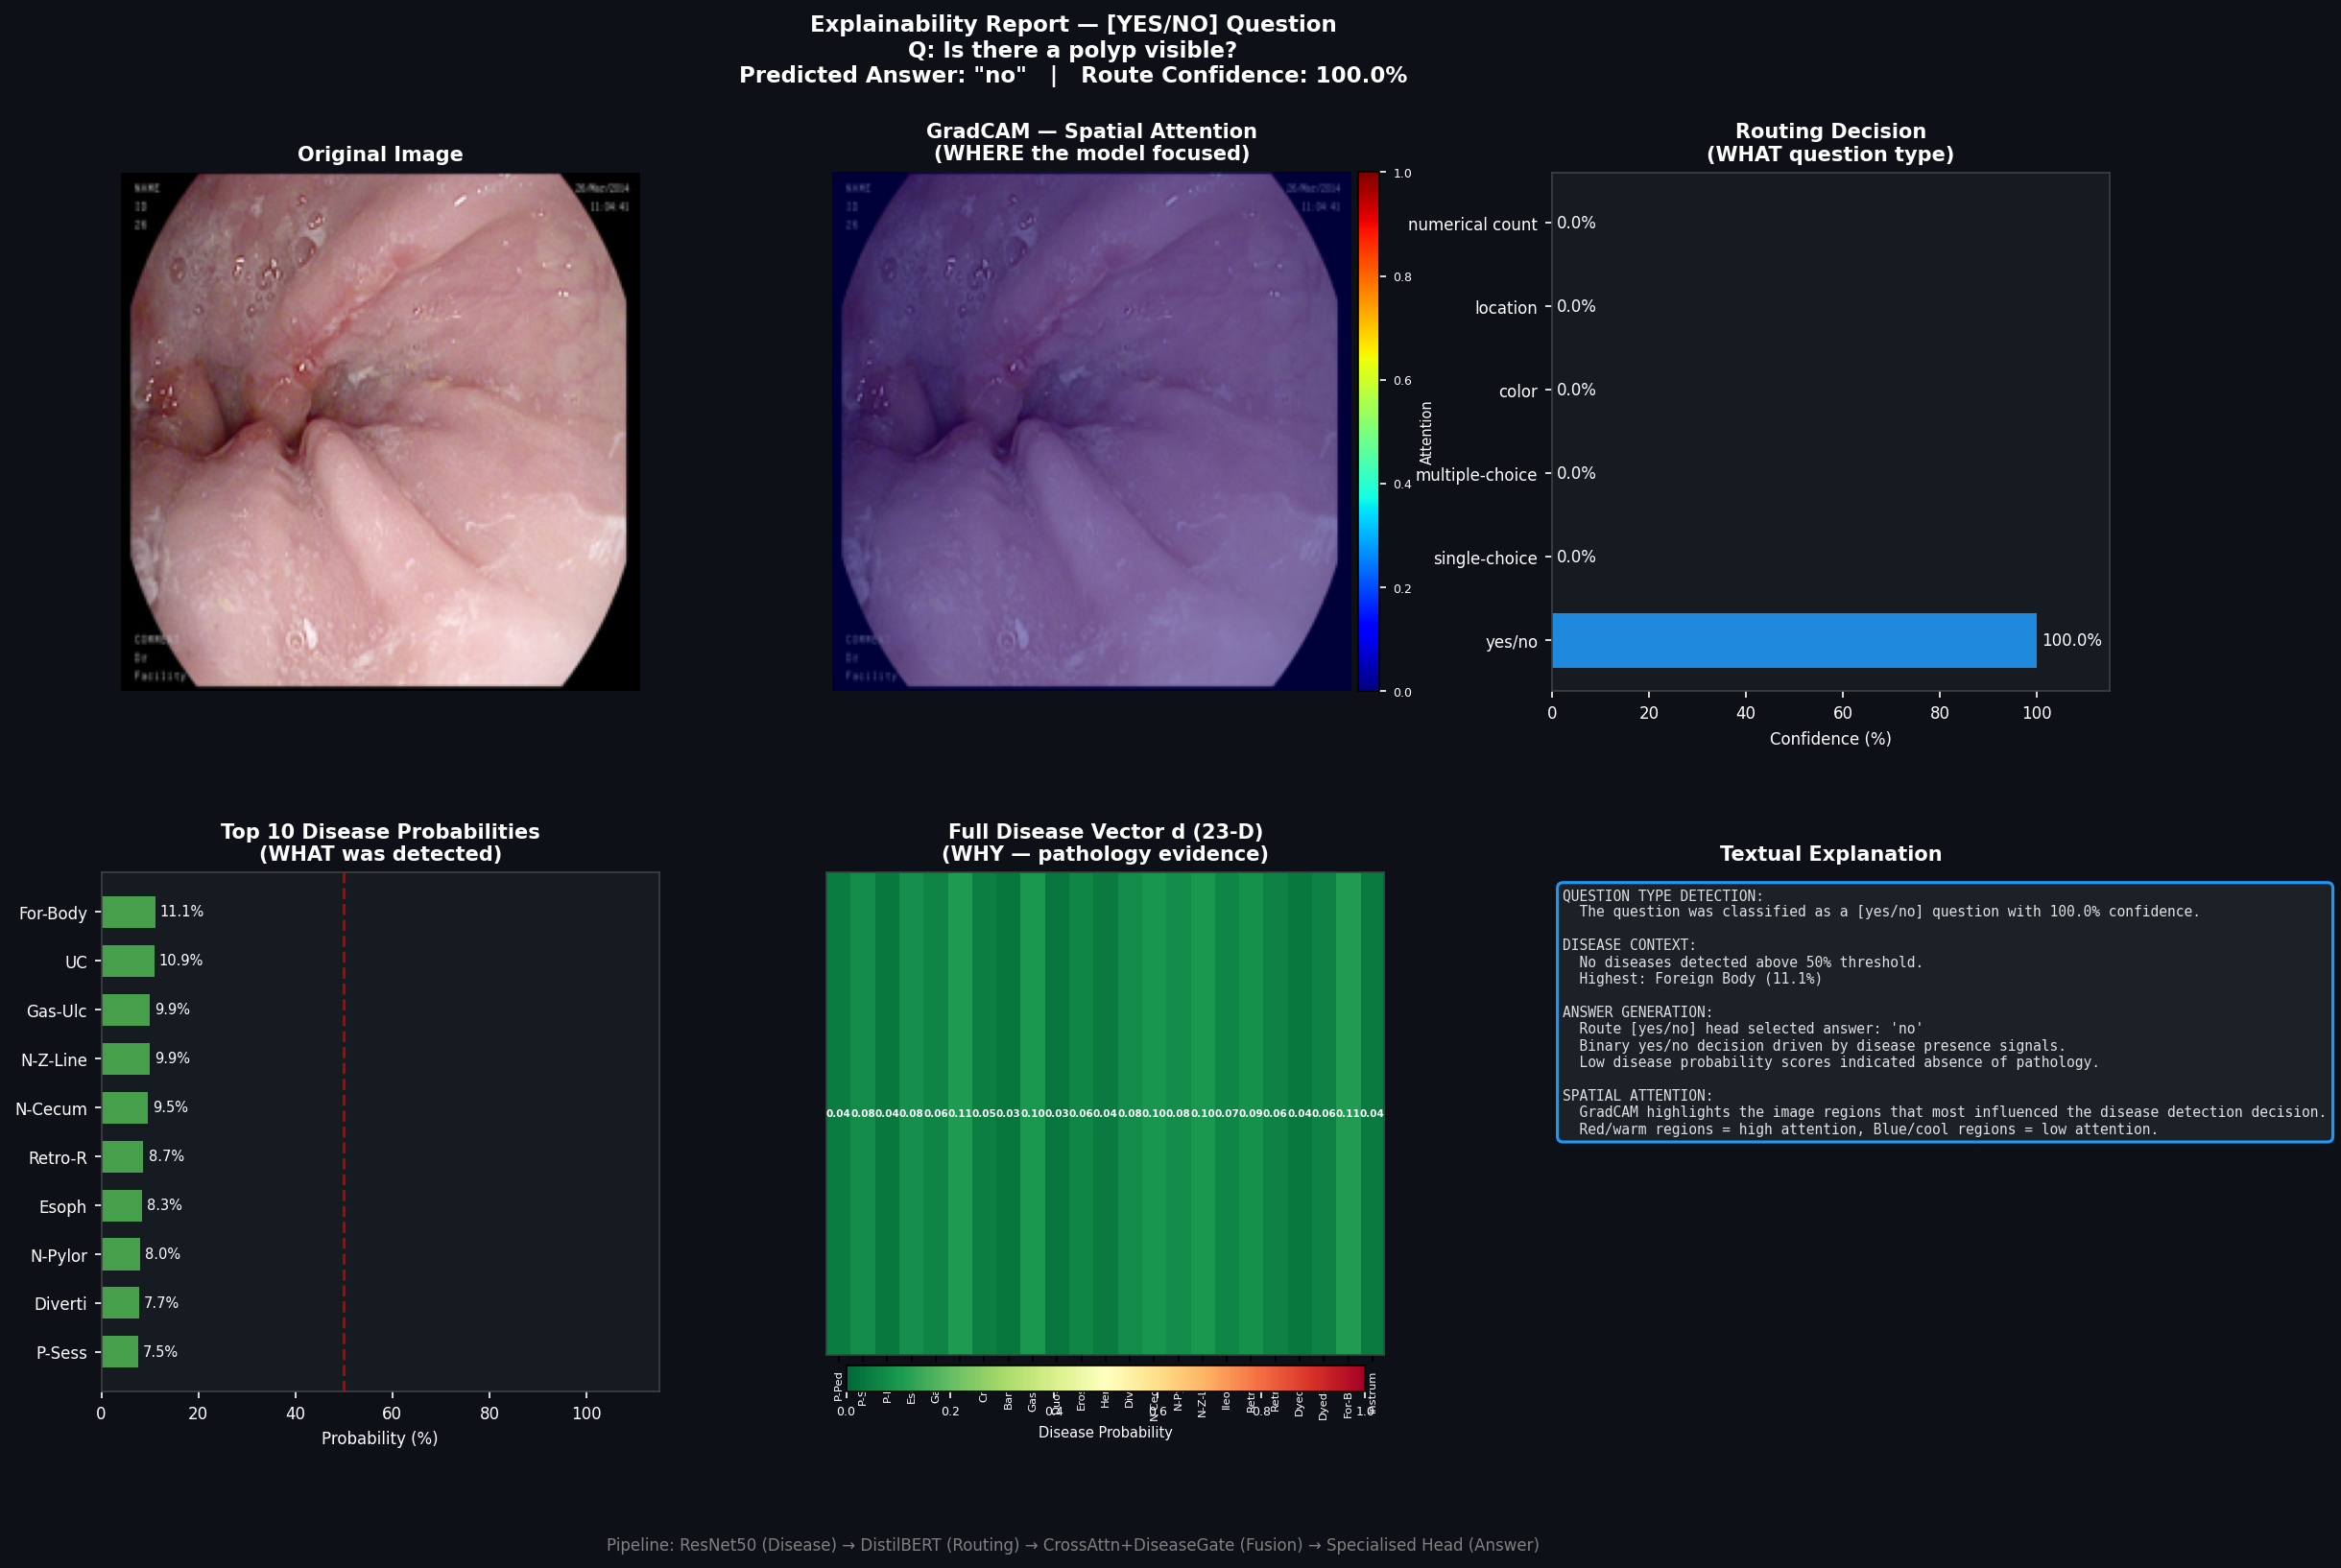

In [13]:
# ─── EDIT THESE ───────────────────────────────────────────────────────────
IMAGE_PATH = './data/kvasir_raw/images/clb0kvxvm90y4074yf50vf5nq.jpg'
QUESTION   = 'Is there a polyp visible?'
# ──────────────────────────────────────────────────────────────────────────

result = predictor.predict_full(IMAGE_PATH, QUESTION)

# Print full explanation
print('=' * 60)
print('FULL EXPLAINABILITY REPORT')
print('=' * 60)
print(f'Question      : {result["question"]}')
print(f'Answer        : {result["answer"].upper()}')
print(f'Question Type : {result["route_name"]}')
print(f'Route Conf    : {result["route_conf"]*100:.2f}%')
print()
print(result['explanation'])
print('=' * 60)

# Show full 6-panel report inline
report_path = plot_explainability_report(result)
display(IPImage(report_path, width=1000))

## 📈 Cell 8 — Pipeline Performance Summary

Stage,Model,Total Params,Trainable,Test Acc,Best Metric
Stage 1,ResNet50 + TreeNet,24.2M,669K,96.86%,Val F1=99.25%
Stage 2,DistilBERT,67.0M,67.0M,93.01%,Macro-F1=88.64%
Stage 3,CrossAttn+DiseaseGate,93.7M,3.2M,92.33%,Val Acc=92.50%
Stage 4,6 Specialised Heads,0.9M,0.9M,73.97%,Val Acc=74.11%


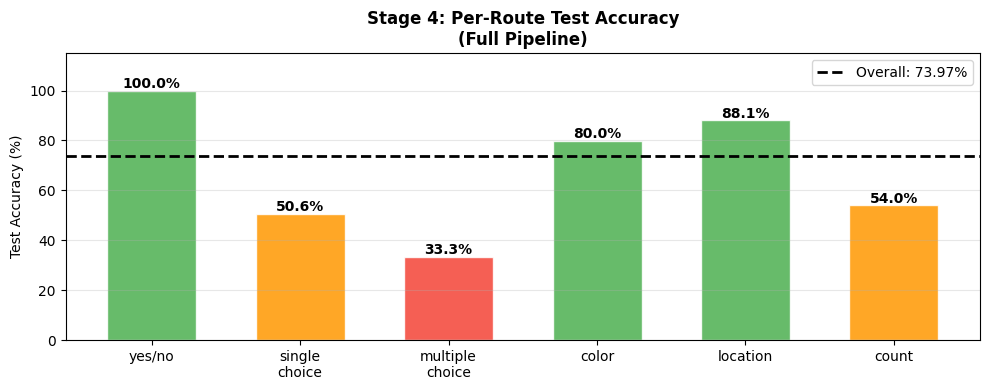

In [14]:
import pandas as pd

# Pipeline summary table
summary = [
    ['Stage 1', 'ResNet50 + TreeNet', '24.2M', '669K', '96.86%', 'Val F1=99.25%'],
    ['Stage 2', 'DistilBERT',          '67.0M', '67.0M','93.01%', 'Macro-F1=88.64%'],
    ['Stage 3', 'CrossAttn+DiseaseGate','93.7M','3.2M', '92.33%', 'Val Acc=92.50%'],
    ['Stage 4', '6 Specialised Heads',  '0.9M', '0.9M', '73.97%', 'Val Acc=74.11%'],
]
df = pd.DataFrame(summary,
    columns=['Stage','Model','Total Params','Trainable','Test Acc','Best Metric'])
display(HTML(df.to_html(index=False,
    classes='table', border=1,
    justify='center').replace('<table',
    '<table style="font-family:monospace; font-size:13px"')))

# Per-route test accuracy bar chart
route_accs = [100.0, 50.59, 33.33, 79.97, 88.06, 54.05]
route_names= ['yes/no','single\nchoice','multiple\nchoice',
              'color','location','count']
colors = ['#4CAF50' if a>=70 else '#FF9800' if a>=50 else '#F44336'
          for a in route_accs]

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(route_names, route_accs, color=colors,
              alpha=0.85, edgecolor='white', width=0.6)
ax.axhline(73.97, color='black', linestyle='--', lw=2,
           label='Overall: 73.97%')
ax.set_ylabel('Test Accuracy (%)')
ax.set_title('Stage 4: Per-Route Test Accuracy\n(Full Pipeline)',
             fontweight='bold')
ax.set_ylim(0, 115)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
for bar, val in zip(bars, route_accs):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
            f'{val:.1f}%', ha='center', fontweight='bold', fontsize=10)
plt.tight_layout()
plt.show()